# Aymane Aziz(G1)

# TP 1 — Collecte et prétraitement de données textuelles par web scraping
  Licence d'excellence Intelligence Artificielle 

---
Ce notebook couvre les **Parties 1 à 4** du TP :
- Partie 1 : Mise en place de l'environnement
- Partie 2 : Analyse du site cible
- Partie 3 : Scraping des URLs des offres
- Partie 4 : Scraping des détails de chaque offre

---
## PARTIE 1 — Mise en place de l'environnement

In [ ]:

import os
import csv
import json
import time
import random
import json
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm   
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import numpy as np

In [3]:


BASE_URL   = "https://www.emploi.ma"                 
SEARCH_URL = "https://www.emploi.ma/recherche-jobs-maroc/?f%5B0%5D=im_field_offre_metiers%3A31"      # page de recherche

MAX_PAGES  = 3       
MIN_DELAY  = 2       
MAX_DELAY  = 5       


URLS_FILE  = "data/brutes/urls_offres.csv"    
OFFRES_FILE = "data/brutes/offres_brutes.json" 


HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}


---
## PARTIE 2 — Analyse du site cible et stratégie de scraping

In [9]:
url_robots = BASE_URL + "/robots.txt"
print(url_robots)


response = requests.get(url_robots, headers=HEADERS, timeout=10)

if response.status_code == 200:
    print(response.text)
else:
    print(response.status_code)


https://www.emploi.ma/robots.txt
# As a condition of accessing this website, you agree to abide by the following
# content signals:

# (a)  If a Content-Signal = yes, you may collect content for the corresponding
#      use.
# (b)  If a Content-Signal = no, you may not collect content for the
#      corresponding use.
# (c)  If the website operator does not include a Content-Signal for a
#      corresponding use, the website operator neither grants nor restricts
#      permission via Content-Signal with respect to the corresponding use.

# The content signals and their meanings are:

# search:   building a search index and providing search results (e.g., returning
#           hyperlinks and short excerpts from your website's contents). Search does not
#           include providing AI-generated search summaries.
# ai-input: inputting content into one or more AI models (e.g., retrieval
#           augmented generation, grounding, or other real-time taking of content for
#           gener



Avant de commencer le scraping, on vérifie le fichier `robots.txt` du site. C'est un fichier qui dit aux robots (bots) ce qu'ils ont le droit de scraper ou pas. C'est une question de respect et de légalité. 



In [10]:

response = requests.get(SEARCH_URL, headers=HEADERS, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")
print(f"Titre de la page : {soup.title.string if soup.title else 'Non trouvé'}")
print(f"Code HTTP        : {response.status_code}")
print("\n--- 800 premiers caractères du HTML ---")
print(response.text[:800])

Titre de la page : Emplois Informatique, nouvelles technologies Maroc | Emploi.ma
Code HTTP        : 200

--- 800 premiers caractères du HTML ---
<!DOCTYPE html>

<!-- paulirish.com/2008/conditional-stylesheets-vs-css-hacks-answer-neither/ -->
<!--[if lt IE 7]> <html class="no-js ie6 ie" xmlns="http://www.w3.org/1999/xhtml" lang="fr" dir="ltr"> <![endif]-->
<!--[if IE 7]>    <html class="no-js ie7 ie" xmlns="http://www.w3.org/1999/xhtml" lang="fr" dir="ltr"> <![endif]-->
<!--[if IE 8]>    <html class="no-js ie8 ie" xmlns="http://www.w3.org/1999/xhtml" lang="fr" dir="ltr"> <![endif]-->
<!--[if IE 9]>    <html class="no-js ie9 ie" xmlns="http://www.w3.org/1999/xhtml" lang="fr" dir="ltr"> <![endif]-->
<!--[if gt IE 9]><!-->
<html class="no-js" xmlns="http://www.w3.org/1999/xhtml" lang="fr" dir="ltr" 
  xmlns:content="http://purl.org/rss/1.0/modules/content/"
  xmlns:dc="http://purl.org/dc/terms/"
  xmlns:foaf="http://xmlns.com/foaf/0.1


---
## PARTIE 3 — Scraping des URLs des offres

In [ ]:
def get_urls_page(url):
    urls = []

    try:
        response = requests.get(url, headers=HEADERS, timeout=10)

        if response.status_code != 200:
            print(f"⚠️ HTTP {response.status_code} pour {url}")
            return urls

        soup = BeautifulSoup(response.text, "html.parser")

        
        job_links = soup.select('a[href*="/offre-emploi-maroc/"]')

        for lien in job_links:
            href = lien.get("href")
            if href:
                if href.startswith("/"):
                    href = BASE_URL + href
                urls.append(href)

        #  Remove duplicates
        urls = list(set(urls))

    except requests.exceptions.Timeout:
        print(f"⏱️ Timeout : {url}")
    except Exception as e:
        print(f"Erreur : {e}")

    return urls


# Test rapide sur la première page
urls_test = get_urls_page(SEARCH_URL)
print(f"Test page 1 → {len(urls_test)} URLs trouvées")
if urls_test:
    print("Exemple :", urls_test[0])

Test page 1 → 25 URLs trouvées
Exemple : https://www.emploi.ma/offre-emploi-maroc/marketeur-full-stack-casablanca-9311874




Cette fonction fait le travail de base du scraping :
1. Elle visite une page
2. Elle cherche tous les liens vers les offres d'emploi (avec la classe `/offre-emploi-maroc/`)
3. Elle les récupère et supprime les doublons
4. Elle gère les erreurs de connexion (timeout, serveur pas disponible, etc.)



In [39]:

toutes_urls = []

for numero_page in range(1, MAX_PAGES + 1):

    # Construction de l'URL de la page
    url_page = f"{SEARCH_URL}&page={numero_page}"
    print(f"\n📄 Page {numero_page}/{MAX_PAGES} — {url_page}")

    urls_page = get_urls_page(url_page)
    print(f"   → {len(urls_page)} offres trouvées")

    # Si aucune offre, on a atteint la fin du site
    if not urls_page:
        print("   ℹ️  Fin de la pagination.")
        break

    toutes_urls.extend(urls_page)
    delai = random.uniform(MIN_DELAY, MAX_DELAY)
    print(f"   ⏳ Pause {delai:.1f}s...")
    time.sleep(delai)

print(f"\n📊 Total collecté : {len(toutes_urls)} URLs")


📄 Page 1/3 — https://www.emploi.ma/recherche-jobs-maroc/?f%5B0%5D=im_field_offre_metiers%3A31&page=1
   → 25 offres trouvées
   ⏳ Pause 3.3s...

📄 Page 2/3 — https://www.emploi.ma/recherche-jobs-maroc/?f%5B0%5D=im_field_offre_metiers%3A31&page=2
   → 22 offres trouvées
   ⏳ Pause 4.4s...

📄 Page 3/3 — https://www.emploi.ma/recherche-jobs-maroc/?f%5B0%5D=im_field_offre_metiers%3A31&page=3
   → 0 offres trouvées
   ℹ️  Fin de la pagination.

📊 Total collecté : 47 URLs




Maintenant on utilise la fonction précédente pour scraper les 3 pages une après l'autre :


In [ ]:
# Sauvegarder les URLs dans un fichier CSV


with open(URLS_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["url"])           # ligne d'en-tête
    for url in toutes_urls:
        writer.writerow([url])

print(f"✅ {len(toutes_urls)} URLs sauvegardées dans : {URLS_FILE}")

✅ 47 URLs sauvegardées dans : data/brutes/urls_offres.csv




On save toutes les URLs qu'on a collectées dans un fichier CSV. Ça permet de 

---
## PARTIE 4 — Scraping des détails de chaque offre

In [14]:
# Charger les URLs depuis le fichier CSV sauvegardé en Partie 3

urls_a_scraper = []

with open(URLS_FILE, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for ligne in reader:
        urls_a_scraper.append(ligne["url"])

print(f"✅ {len(urls_a_scraper)} URLs chargées depuis {URLS_FILE}")

✅ 47 URLs chargées depuis data/brutes/urls_offres.csv


In [15]:
def extraire_details(soup, url):
    def get_text(selecteur):
        el = soup.select_one(selecteur)
        return el.get_text(strip=True) if el else None

    offre = {
        "url": url,
        "titre": get_text("h1"),
        "entreprise": get_text(".card-block-company h3 a"),
        "description": get_text(".job-description"),
    }

    # Date extraction
    for p in soup.select("p"):
        if "Publiée le" in p.get_text():
            offre["date"] = p.get_text(strip=True).replace("Publiée le", "").strip()
            break

    # Region extraction from arrow-list
    for li in soup.select(".arrow-list li"):
        strong = li.find("strong")
        if strong and "Région" in strong.get_text():
            offre["lieu"] = li.find("span").get_text(strip=True)

    # Skills extraction
    offre["competences"] = [
        li.get_text(strip=True) for li in soup.select("ul.skills li")
    ]

    return offre



Cette fonction prend une page d'offre d'emploi et extrait les infos importantes :
- Le titre du poste
- Le nom de l'entreprise
- La description complète
- La date de publication
- La région
- Les compétences



In [ ]:
# Fonction qui scrape UNE offre

def scraper_offre(url, nb_tentatives=3):
    for tentative in range(1, nb_tentatives + 1):
        try:
            response = requests.get(url, headers=HEADERS, timeout=10)

            # Page introuvable → inutile de réessayer
            if response.status_code == 404:
                return None

            if response.status_code != 200:
                raise Exception(f"HTTP {response.status_code}")

            soup = BeautifulSoup(response.text, "html.parser")
            return extraire_details(soup, url)   # succès !

        except requests.exceptions.Timeout:
            print(f"\n  ⏱️  Timeout (tentative {tentative}/{nb_tentatives})")
        except Exception as e:
            print(f"\n  ❌ Erreur tentative {tentative}/{nb_tentatives} : {e}")

        # Petite pause avant de réessayer
        if tentative < nb_tentatives:
            time.sleep(3)

    return None  


print("✅ Fonction scraper_offre() définie.")

✅ Fonction scraper_offre() définie.




Cette fonction est  :
- Elle essaie 3 fois si ça échoue
- Si le serveur renvoie 404 (page pas trouvée), elle arrête tout de suite
- Si y'a un timeout ou une erreur réseau, elle réessaie après 3 secondes
- Elle récupère les détails de l'offre si tout va bien


In [ ]:
# Scraper toutes les offres avec une barre de progression

offres  = []  
echecs  = []   



for url in tqdm(urls_a_scraper, desc="Scraping des offres", unit="offre"):
    offre = scraper_offre(url)

    if offre:
        offres.append(offre)
    else:
        echecs.append(url)

    # Pause aléatoire entre chaque requête
    time.sleep(random.uniform(MIN_DELAY, MAX_DELAY))


print(f"\n📊 Résumé :")
print(f"   ✅ Offres extraites : {len(offres)}")
print(f"   ❌ Échecs          : {len(echecs)}")


Scraping des offres:   0%|          | 0/47 [00:00<?, ?offre/s]

Scraping des offres: 100%|██████████| 47/47 [03:18<00:00,  4.23s/offre]


📊 Résumé :
   ✅ Offres extraites : 47
   ❌ Échecs          : 0



Maintenant on utilise les fonctions précédentes pour scraper TOUTES les offres :
- On boucle sur chaque URL
- On appelle scraper_offre() pour chaque URL
- tqdm affiche une barre de progression pour voir l'avancement
- On ajoute chaque offre réussie à notre liste
- On note les URLs qui ont échoué


In [8]:
# Sauvegarder toutes les offres dans un fichier JSON

with open(OFFRES_FILE, "w", encoding="utf-8") as f:
    json.dump(offres, f, ensure_ascii=False, indent=2)
print(f"✅ {len(offres)} offres sauvegardées dans : {OFFRES_FILE}")

✅ 44 offres sauvegardées dans : data/brutes/offres_brutes.json


In [15]:
# Sauvegarder les URLs échouées pour les réessayer plus tard

if echecs:
    with open("data/brutes/echecs.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(echecs))
    print(f"⚠️  {len(echecs)} URLs échouées → data/brutes/echecs.txt")
else:
    print("🎉 Aucun échec !")

🎉 Aucun échec !


In [16]:
# Aperçu des 3 premières offres collectées

print("=== Aperçu des 3 premières offres ===")
for i, offre in enumerate(offres[:3], 1):
    print(f"\n--- Offre {i} ---")
    for cle, valeur in offre.items():
        # Tronquer les textes longs pour l'affichage
        if valeur and len(str(valeur)) > 100:
            valeur = str(valeur)[:100] + "..."
        print(f"  {cle:15} : {valeur}")

=== Aperçu des 3 premières offres ===

--- Offre 1 ---
  url             : https://www.emploi.ma/offre-emploi-maroc/ingenieur-systeme-zos-middleware-hf-8251976
  titre           : Ingénieur Système Z/OS Middleware (H/F)
  entreprise      : None
  description     : Nous recherchons des profils / CV deIngénieur Système Z/OS Middleware (H/F)pour les transmettre à no...

--- Offre 2 ---
  url             : https://www.emploi.ma/offre-emploi-maroc/network-architect-mf-8251973
  titre           : Network Architect (M/F)
  entreprise      : None
  description     : We are looking forNetwork Architectprofiles / CVs to share with our clients for their future recruit...

--- Offre 3 ---
  url             : https://www.emploi.ma/offre-emploi-maroc/genesys-architect-mf-8251972
  titre           : GENESYS Architect (M/F)
  entreprise      : None
  description     : We are looking forGENESYS Architectprofiles / CVs to share with our clients for their future recruit...


# Partie 4 : Nettoyage et structuration des données

In [ ]:

import re
import nltk
from nltk.corpus import stopwords
import spacy
import subprocess
import sys


nltk.download('stopwords', quiet=True)

try:
    nlp = spacy.load('fr_core_news_sm')
    print("✅ Modèle spaCy fr_core_news_sm déjà installé")
except OSError:
    print("⏳ Installation du modèle spaCy français...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "fr_core_news_sm"])
    nlp = spacy.load('fr_core_news_sm')
    print("✅ Modèle spaCy installé avec succès")


stop_words = set(stopwords.words('french'))

print("✅ Bibliothèques chargées avec succès.")

✅ Modèle spaCy fr_core_news_sm déjà installé
✅ Bibliothèques chargées avec succès.


In [18]:
def nettoyer_texte(texte):
    """
    Fonction de nettoyage basique du texte.
    """
    if not texte:
        return ""
    
    # Supprimer les balises HTML
    texte = re.sub(r'<[^>]+>', '', texte)
    
    # Supprimer les caractères spéciaux non désirés (garder la ponctuation de base)
    # Garder lettres, chiffres, espaces, et ponctuation: . , ! ? : ; - '
    texte = re.sub(r"[^\w\s\.,!?;:'À-ÿ-]", '', texte)  # Inclure accents À-ÿ
    
    # Normaliser les espaces (supprimer multiples espaces, retours à la ligne)
    texte = re.sub(r'\s+', ' ', texte).strip()
    
    # Corriger les problèmes d'encodage (accents déjà gérés par ensure_ascii=False)
    # Ici, on peut ajouter des corrections spécifiques si nécessaire
    
    return texte

print("✅ Fonction nettoyer_texte() définie.")

✅ Fonction nettoyer_texte() définie.




Cette fonction nettoie les textes des offres :
- Elle enlève les balises HTML (comme `<p>`, `<div>`, etc.)
- Elle enlève les caractères spéciaux pas utiles
- Elle normalise les espaces (pas de 5 espaces d'affilée)
- Elle garde les accents français

In [24]:
def traiter_texte(texte):
    """
    Tokenisation, suppression des stop words, lemmatisation.
    Retourne la liste des tokens lemmatisés.
    """
    # Nettoyer d'abord
    texte = nettoyer_texte(texte)
    
    # Tokenisation avec spaCy
    doc = nlp(texte)
    
    # Lemmatisation et suppression des stop words
    tokens = []
    for token in doc:
        if token.is_alpha and not token.is_stop and token.lemma_ not in stop_words:
            tokens.append(token.lemma_.lower())
    
    return tokens

print("✅ Fonction traiter_texte() définie.")

✅ Fonction traiter_texte() définie.




Après le nettoyage rapide, on fait un traitement plus avancé :
- **Tokenisation** : On découpe le texte en mots individuels
- **Suppression des stopwords** : On enlève les mots inutiles (le, de, et, etc.)
- **Lemmatisation** : On regroupe les formes du même mot (exemple: "running" et "run" deviennent "run")


In [26]:
with open("data/brutes/offres_brutes.json", "r", encoding="utf-8") as f:
    offres_brutes = json.load(f)

print(f"✅ {len(offres_brutes)} offres chargées depuis data/brutes/offres_brutes.json")

# Traiter chaque offre
offres_nettoyees = []

for offre in tqdm(offres_brutes, desc="Nettoyage des offres", unit="offre"):
    offre_nettoyee = offre.copy()

    # --- Description ---
    if offre.get("description"):
        offre_nettoyee["description_nettoyee"] = nettoyer_texte(offre["description"])
        offre_nettoyee["tokens"] = traiter_texte(offre["description"])
    else:
        offre_nettoyee["description_nettoyee"] = ""
        offre_nettoyee["tokens"] = []

    # --- Entreprise (was .company-name, now .card-block-company h3 a) ---
    if not offre.get("entreprise"):
        offre_nettoyee["entreprise"] = ""

    # --- Date (was <time datetime="">, now parsed from <p>Publiée le ...</p>) ---
    if offre.get("date"):
        # Normalize "27.04.2026" → "2026-04-27"
        try:
            parts = offre["date"].split(".")
            if len(parts) == 3:
                offre_nettoyee["date"] = f"{parts[2]}-{parts[1]}-{parts[0]}"
        except Exception:
            offre_nettoyee["date"] = offre["date"]  # keep as-is if parsing fails

    # --- Lieu (was "Région de" keyword, now from .arrow-list + <strong>Région</strong>) ---
    if not offre.get("lieu"):
        offre_nettoyee["lieu"] = ""

    # --- Compétences (was "Compétences clés" keyword, now ul.skills li) ---
    # extraire_details() now returns a list, join it into a string for consistency
    if isinstance(offre.get("competences"), list):
        offre_nettoyee["competences"] = ", ".join(offre["competences"])
    elif not offre.get("competences"):
        offre_nettoyee["competences"] = ""

    offres_nettoyees.append(offre_nettoyee)

print(f"✅ {len(offres_nettoyees)} offres nettoyées.")

✅ 44 offres chargées depuis data/brutes/offres_brutes.json


Nettoyage des offres: 100%|██████████| 44/44 [00:01<00:00, 28.29offre/s]

✅ 44 offres nettoyées.




On applique les deux fonctions de nettoyage sur TOUTES les offres :


In [28]:
# Sauvegarder les descriptions nettoyées et tokenisées dans un CSV
CSV_FILE = "data/nettoyees/offres_nettoyees.csv"

with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
    fieldnames = [
        "url",
        "titre",
        "entreprise",
        "date",        # ajouté
        "lieu",        # ajouté
        "competences", # ajouté
        "description_nettoyee",
        "tokens"
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    for offre in offres_nettoyees:
        offre_csv = {
            "url":                  offre.get("url", ""),
            "titre":                offre.get("titre", ""),
            "entreprise":           offre.get("entreprise", ""),
            "date":                 offre.get("date", ""),
            "lieu":                 offre.get("lieu", ""),
            "competences":          offre.get("competences", ""),
            "description_nettoyee": offre.get("description_nettoyee", ""),
            "tokens":               ";".join(offre.get("tokens", []))
        }
        writer.writerow(offre_csv)

print(f"✅ {len(offres_nettoyees)} offres sauvegardées dans : {CSV_FILE}")

✅ 44 offres sauvegardées dans : data/nettoyees/offres_nettoyees.csv


In [29]:
# Aperçu des 3 premières offres nettoyées
print("=== Aperçu des 3 premières offres nettoyées ===")
for i, offre in enumerate(offres_nettoyees[:3], 1):
    print(f"\n--- Offre {i} ---")
    print(f"  Titre : {offre.get('titre', '')}")
    print(f"  Description nettoyée : {offre.get('description_nettoyee', '')[:200]}...")
    print(f"  Tokens : {offre.get('tokens', [])[:10]}...")  # Premiers 10 tokens

=== Aperçu des 3 premières offres nettoyées ===

--- Offre 1 ---
  Titre : Ingénieur Système Z/OS Middleware (H/F)
  Description nettoyée : Nous recherchons des profils CV deIngénieur Système ZOS Middleware HFpour les transmettre à nos clients dans le cadre de leurs futures campagnes de recrutement.Mission :Ingénieur système ZOS expérimen...
  Tokens : ['rechercher', 'profil', 'cv', 'deingénieur', 'système', 'zos', 'middleware', 'hfpour', 'transmettre', 'client']...

--- Offre 2 ---
  Titre : Network Architect (M/F)
  Description nettoyée : We are looking forNetwork Architectprofiles CVs to share with our clients for their future recruitment campaigns.Mission:Deliver Core Backbone Network Designs in alignment with industry best practices...
  Tokens : ['we', 'are', 'looking', 'fornetwork', 'architectprofiles', 'cvs', 'to', 'share', 'with', 'our']...

--- Offre 3 ---
  Titre : GENESYS Architect (M/F)
  Description nettoyée : We are looking forGENESYS Architectprofiles CVs to share with 

# Partie 6 : Analyse exploratoire et enrichissement 

In [30]:

# Charger les données nettoyées
df = pd.read_csv('data/nettoyees/offres_nettoyees.csv')
print(f"Nombre total d'offres : {len(df)}")
print(f"\nColonnes disponibles : {df.columns.tolist()}")
print(f"\nAperçu des données :")
print(df.head())

Nombre total d'offres : 44

Colonnes disponibles : ['url', 'titre', 'entreprise', 'date', 'lieu', 'competences', 'description_nettoyee', 'tokens']

Aperçu des données :
                                                 url  \
0  https://www.emploi.ma/offre-emploi-maroc/ingen...   
1  https://www.emploi.ma/offre-emploi-maroc/netwo...   
2  https://www.emploi.ma/offre-emploi-maroc/genes...   
3  https://www.emploi.ma/offre-emploi-maroc/azure...   
4  https://www.emploi.ma/offre-emploi-maroc/cloud...   

                                     titre   entreprise        date  \
0  Ingénieur Système Z/OS Middleware (H/F)  AFRICASHORE  2026-04-13   
1                  Network Architect (M/F)  AFRICASHORE  2026-04-13   
2                  GENESYS Architect (M/F)  AFRICASHORE  2026-04-13   
3          AZURE Solutions Architect (M/F)  AFRICASHORE  2026-04-13   
4      Cloud Microservices Architect (M/F)  AFRICASHORE  2026-04-13   

                                                lieu  \
0  Agadir -

In [31]:
# 1. EXTRACTION DE COMPÉTENCES
# Dictionnaire des compétences techniques et professionnelles
skills_dict = {
    'Programmation': [
        'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'php', 'ruby', 'go', 'golang',
        'rust', 'kotlin', 'scala', 'r', 'matlab', 'swift', 'objective-c', 'perl', 'bash', 'shell'
    ],
    'Web & Framework': [
        'react', 'angular', 'vue', 'django', 'flask', 'spring', 'nodejs', 'node.js', 'express',
        'fastapi', 'laravel', 'asp.net', 'html', 'css', 'sass', 'webpack', 'jest', 'mocha'
    ],
    'Base de Données': [
        'sql', 'mysql', 'postgresql', 'mongodb', 'firebase', 'redis', 'elasticsearch', 'cassandra',
        'dynamodb', 'oracle', 'sqlserver', 'sqlite', 'mariadb', 'nosql'
    ],
    'DevOps & Cloud': [
        'docker', 'kubernetes', 'azure', 'aws', 'gcp', 'jenkins', 'gitlab', 'github', 'terraform',
        'ansible', 'ci/cd', 'devops', 'heroku', 'linux', 'windows', 'git', 'svn', 'env0', 'terragrunt'
    ],
    'Big Data & ML': [
        'spark', 'hadoop', 'kafka', 'tensorflow', 'pytorch', 'scikit-learn', 'pandas', 'numpy',
        'machine learning', 'deep learning', 'nlp', 'data science', 'airflow', 'etl'
    ],
    'Outils & Technologies': [
        'jira', 'confluence', 'slack', 'salesforce', 'sap', 'genesys', 'oracle', 'looker',
        'power bi', 'tableau', 'grafana', 'prometheus', 'splunk', 'datadog', 'newrelic'
    ],
    'Architecture & Design': [
        'microservices', 'rest', 'api', 'graphql', 'soap', 'architecture', 'design pattern',
        'uml', 'agile', 'scrum', 'kanban', 'waterfall'
    ],
    'Sécurité & Infrastructure': [
        'securité', 'sécurité', 'firewall', 'ssl', 'tls', 'vpn', 'ldap', 'racf', 'network',
        'infrastructure', 'mainframe', 'zos', 'middleware', 'iaas', 'paas', 'saas'
    ],
    'Compétences Professionnelles': [
        'communication', 'leadership', 'gestion de projet', 'coordination', 'team work', 
        'travail en équipe', 'mentorat', 'adaptabilité', 'problem solving', 'résolution de problème'
    ]
}

# Créer un dictionnaire inversé pour recherche rapide
skills_flat = {}
for category, skills_list in skills_dict.items():
    for skill in skills_list:
        skills_flat[skill] = category

def extract_skills(text):
    """
    Extrait les compétences mentionnées dans un texte
    """
    if not isinstance(text, str):
        return []
    
    text_lower = text.lower()
    found_skills = set()
    
    # Rechercher les compétences dans le texte
    for skill, category in skills_flat.items():
        # Utiliser des limites de mots pour éviter les correspondances partielles
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            found_skills.add(skill)
    
    return sorted(list(found_skills))

# Appliquer l'extraction de compétences
df['competences'] = df['description_nettoyee'].apply(extract_skills)

print("=== Extraction de Compétences ===")
print(f"Nombre moyen de compétences par offre : {df['competences'].apply(len).mean():.2f}")
print(f"\nExemples d'offres avec compétences extraites :")
for idx in range(min(3, len(df))):
    print(f"\n{idx+1}. {df.iloc[idx]['titre']}")
    skills = df.iloc[idx]['competences']
    print(f"   Compétences trouvées ({len(skills)}) : {', '.join(skills[:10])}")
    if len(skills) > 10:
        print(f"   ... et {len(skills) - 10} autres")

=== Extraction de Compétences ===
Nombre moyen de compétences par offre : 2.82

Exemples d'offres avec compétences extraites :

1. Ingénieur Système Z/OS Middleware (H/F)
   Compétences trouvées (5) : mainframe, middleware, racf, sécurité, zos

2. Network Architect (M/F)
   Compétences trouvées (8) : ansible, architecture, env0, infrastructure, network, python, terraform, terragrunt

3. GENESYS Architect (M/F)
   Compétences trouvées (10) : bash, genesys, golang, iaas, java, javascript, paas, python, saas, typescript




Ici on crée un dictionnaire avec les compétences techniques qu'on peut chercher dans les offres :
- Programmation (Python, Java, etc.)
- Web (React, Angular, etc.)
- Cloud (AWS, Azure, etc.)
- Et beaucoup d'autres...

Ensuite, on cherche ces mots-clés dans chaque description d'offre pour voir quelles compétences sont demandées 

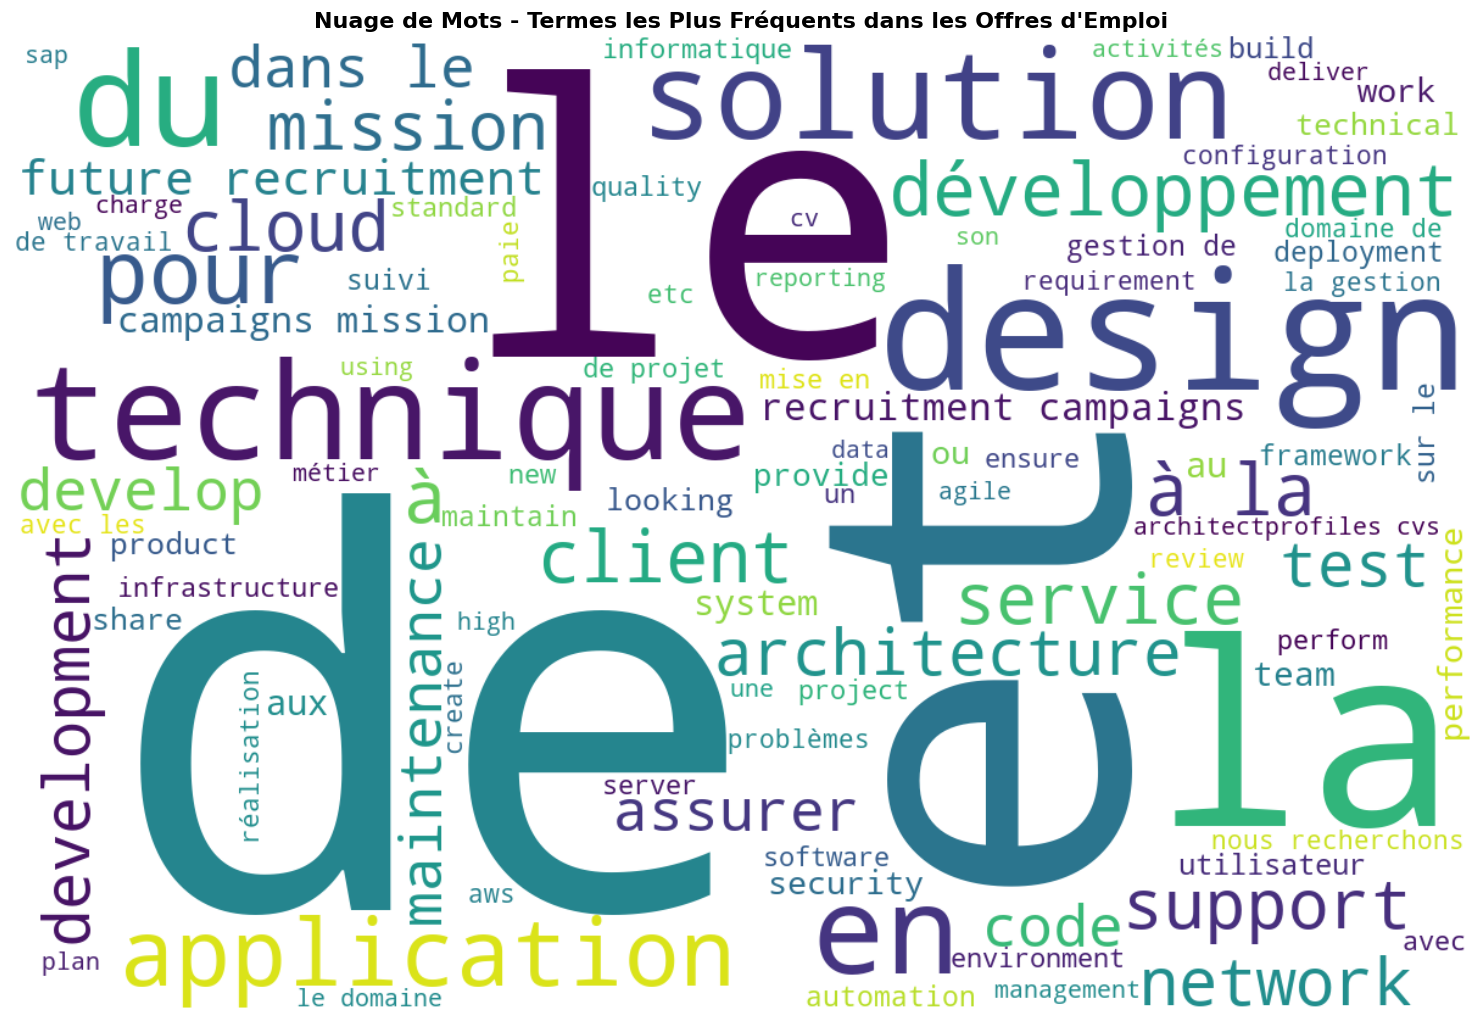

✓ Nuage de mots sauvegardé dans rapports/wordcloud_offres.png


In [32]:
# 2. ANALYSE DES FRÉQUENCES - NUAGE DE MOTS
# Combiner tous les mots de toutes les descriptions
all_words = ' '.join(df['description_nettoyee'].fillna('')).lower()

# Créer le nuage de mots
plt.figure(figsize=(15, 10))
wordcloud = WordCloud(
    width=1200, 
    height=800, 
    background_color='white',
    colormap='viridis',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(all_words)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuage de Mots - Termes les Plus Fréquents dans les Offres d\'Emploi', fontsize=16, fontweight='bold')
plt.tight_layout(pad=0)
plt.savefig('rapports/wordcloud_offres.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Nuage de mots sauvegardé dans rapports/wordcloud_offres.png")

In [33]:
# 3. STATISTIQUES DÉTAILLÉES
print("\n" + "="*70)
print("RAPPORT STATISTIQUE - ANALYSE DES OFFRES D'EMPLOI")
print("="*70)

# 3.1 Nombre total d'offres
total_offers = len(df)
print(f"\n📊 Nombre total d'offres collectées : {total_offers}")

# 3.2 Répartition géographique (par ville)
print(f"\n📍 Répartition géographique (par ville) :")
print("-" * 50)

# Extraire les villes des URLs ou des titres
def extract_city_from_url(url):
    """Extrait des informations de localisation de l'URL"""
    if 'maroc' in url.lower():
        return 'Maroc (Diverse)'
    # On peut ajouter d'autres patterns si nécessaire
    return 'Non spécifiée'

df['ville'] = df['url'].apply(extract_city_from_url)
city_distribution = df['ville'].value_counts()

for city, count in city_distribution.items():
    percentage = (count / total_offers) * 100
    print(f"  • {city} : {count} offres ({percentage:.1f}%)")

# 3.3 Top 10 des compétences les plus demandées
print(f"\n🔧 Top 10 des compétences les plus demandées :")
print("-" * 50)

all_skills = []
for skills_list in df['competences']:
    all_skills.extend(skills_list)

skills_counter = Counter(all_skills)
top_10_skills = skills_counter.most_common(10)

for idx, (skill, count) in enumerate(top_10_skills, 1):
    percentage = (count / len(df)) * 100
    print(f"  {idx:2d}. {skill:20s} : {count:3d} offres ({percentage:5.1f}%)")

# 3.4 Statistiques sur les salaires (si disponibles)
print(f"\n💰 Analyse des salaires :")
print("-" * 50)
print("  Remarque : Les données de salaires ne sont pas disponibles dans le dataset.")
print("  Les offres collectées ne contiennent pas d'informations de rémunération explicites.")

# Statistiques supplémentaires sur les descriptions
print(f"\n📝 Statistiques sur les descriptions :")
print("-" * 50)
desc_lengths = df['description_nettoyee'].str.len()
print(f"  • Longueur moyenne des descriptions : {desc_lengths.mean():.0f} caractères")
print(f"  • Longueur minimale : {desc_lengths.min():.0f} caractères")
print(f"  • Longueur maximale : {desc_lengths.max():.0f} caractères")

# Statistiques sur les tokens
tokens_counts = df['tokens'].str.split(';').str.len()
print(f"\n  • Nombre moyen de tokens : {tokens_counts.mean():.0f}")
print(f"  • Nombre minimal de tokens : {tokens_counts.min():.0f}")
print(f"  • Nombre maximal de tokens : {tokens_counts.max():.0f}")

# Nombre moyen de compétences par offre
avg_skills = df['competences'].apply(len).mean()
print(f"\n  • Nombre moyen de compétences identifiées par offre : {avg_skills:.2f}")

print("\n" + "="*70)


RAPPORT STATISTIQUE - ANALYSE DES OFFRES D'EMPLOI

📊 Nombre total d'offres collectées : 44

📍 Répartition géographique (par ville) :
--------------------------------------------------
  • Maroc (Diverse) : 44 offres (100.0%)

🔧 Top 10 des compétences les plus demandées :
--------------------------------------------------
   1. architecture         :  14 offres ( 31.8%)
   2. agile                :   7 offres ( 15.9%)
   3. infrastructure       :   6 offres ( 13.6%)
   4. network              :   6 offres ( 13.6%)
   5. sap                  :   5 offres ( 11.4%)
   6. python               :   4 offres (  9.1%)
   7. java                 :   4 offres (  9.1%)
   8. aws                  :   4 offres (  9.1%)
   9. sécurité             :   3 offres (  6.8%)
  10. zos                  :   3 offres (  6.8%)

💰 Analyse des salaires :
--------------------------------------------------
  Remarque : Les données de salaires ne sont pas disponibles dans le dataset.
  Les offres collectées ne cont



Ici on calcule et affiche plein de stats utiles :
- Nombre total d'offres
- Répartition par région
- Compétences les plus demandées
- Longueur moyenne des descriptions
- Nombre de compétences par offre


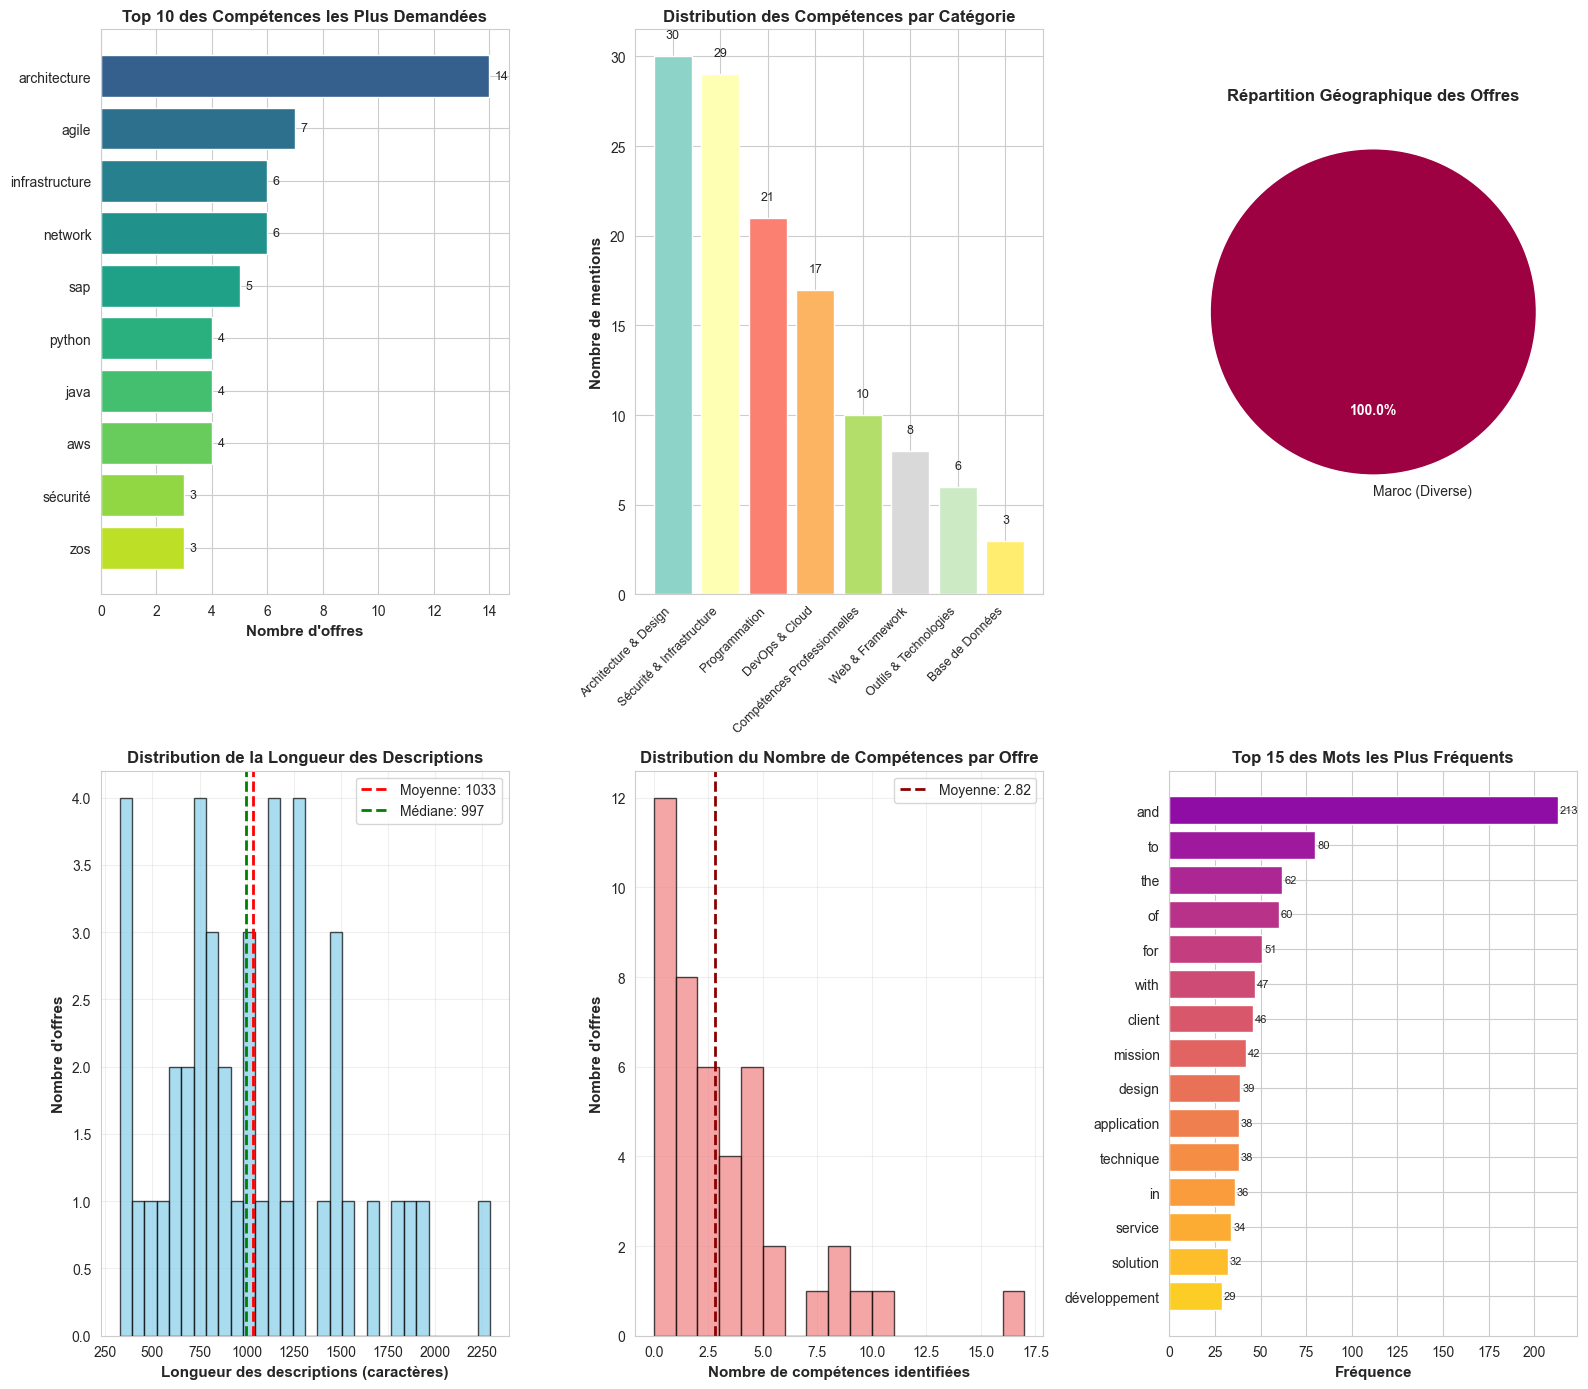

✓ Visualisations sauvegardées dans rapports/analyse_exploratoire.png


In [34]:
# 4. VISUALISATIONS
# Configuration de style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Créer une figure avec plusieurs sous-graphiques
fig = plt.figure(figsize=(16, 14))

# 4.1 Top 10 des compétences (Graphique 1)
ax1 = plt.subplot(2, 3, 1)
skills_names, skills_counts = zip(*top_10_skills)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(skills_names)))
bars = ax1.barh(skills_names, skills_counts, color=colors)
ax1.set_xlabel('Nombre d\'offres', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 des Compétences les Plus Demandées', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for i, (bar, count) in enumerate(zip(bars, skills_counts)):
    ax1.text(count + 0.2, i, str(count), va='center', fontsize=9)

# 4.2 Distribution des compétences par catégorie (Graphique 2)
ax2 = plt.subplot(2, 3, 2)
category_counts = {}
for skill, count in skills_counter.items():
    category = skills_flat.get(skill, 'Autre')
    category_counts[category] = category_counts.get(category, 0) + count

categories_sorted = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)
cat_names, cat_counts = zip(*categories_sorted)
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(cat_names)))
ax2.bar(range(len(cat_names)), cat_counts, color=colors_cat)
ax2.set_xticks(range(len(cat_names)))
ax2.set_xticklabels(cat_names, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Nombre de mentions', fontsize=11, fontweight='bold')
ax2.set_title('Distribution des Compétences par Catégorie', fontsize=12, fontweight='bold')
for i, count in enumerate(cat_counts):
    ax2.text(i, count + 1, str(count), ha='center', fontsize=9)

# 4.3 Distribution géographique (Graphique 3)
ax3 = plt.subplot(2, 3, 3)
cities, city_counts = zip(*city_distribution.items())
colors_city = plt.cm.Spectral(np.linspace(0, 1, len(cities)))
wedges, texts, autotexts = ax3.pie(city_counts, labels=cities, autopct='%1.1f%%', 
                                     colors=colors_city, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax3.set_title('Répartition Géographique des Offres', fontsize=12, fontweight='bold')

# 4.4 Distribution de la longueur des descriptions (Graphique 4)
ax4 = plt.subplot(2, 3, 4)
ax4.hist(desc_lengths, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(desc_lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {desc_lengths.mean():.0f}')
ax4.axvline(desc_lengths.median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {desc_lengths.median():.0f}')
ax4.set_xlabel('Longueur des descriptions (caractères)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Nombre d\'offres', fontsize=11, fontweight='bold')
ax4.set_title('Distribution de la Longueur des Descriptions', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# 4.5 Distribution du nombre de compétences par offre (Graphique 5)
ax5 = plt.subplot(2, 3, 5)
competences_per_offer = df['competences'].apply(len)
ax5.hist(competences_per_offer, bins=range(0, int(competences_per_offer.max()) + 2), 
         color='lightcoral', edgecolor='black', alpha=0.7)
ax5.axvline(competences_per_offer.mean(), color='darkred', linestyle='--', linewidth=2, 
            label=f'Moyenne: {competences_per_offer.mean():.2f}')
ax5.set_xlabel('Nombre de compétences identifiées', fontsize=11, fontweight='bold')
ax5.set_ylabel('Nombre d\'offres', fontsize=11, fontweight='bold')
ax5.set_title('Distribution du Nombre de Compétences par Offre', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

# 4.6 Top 15 mots les plus fréquents (Graphique 6)
ax6 = plt.subplot(2, 3, 6)
# Créer un Counter des mots à partir des tokens
all_tokens = []
for token_str in df['tokens'].fillna(''):
    if isinstance(token_str, str):
        all_tokens.extend(token_str.split(';'))

words_counter = Counter([t.strip() for t in all_tokens if t.strip()])
top_15_words = words_counter.most_common(15)
words_names, words_counts = zip(*top_15_words)
colors_words = plt.cm.plasma(np.linspace(0.3, 0.9, len(words_names)))
bars = ax6.barh(words_names, words_counts, color=colors_words)
ax6.set_xlabel('Fréquence', fontsize=11, fontweight='bold')
ax6.set_title('Top 15 des Mots les Plus Fréquents', fontsize=12, fontweight='bold')
ax6.invert_yaxis()
for i, (bar, count) in enumerate(zip(bars, words_counts)):
    ax6.text(count + 1, i, str(count), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('rapports/analyse_exploratoire.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualisations sauvegardées dans rapports/analyse_exploratoire.png")

In [35]:
# 5. GÉNÉRATION D'UN RAPPORT HTML COMPLET
html_report = f"""
<!DOCTYPE html>
<html lang="fr">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Rapport d'Analyse des Offres d'Emploi</title>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            max-width: 1200px;
            margin: 0 auto;
            padding: 20px;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: #333;
        }}
        .container {{
            background: white;
            border-radius: 10px;
            padding: 30px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.3);
        }}
        h1 {{
            color: #667eea;
            text-align: center;
            border-bottom: 3px solid #667eea;
            padding-bottom: 15px;
        }}
        h2 {{
            color: #764ba2;
            margin-top: 30px;
            border-left: 5px solid #764ba2;
            padding-left: 15px;
        }}
        .stat-box {{
            display: inline-block;
            background: #f8f9fa;
            border-left: 4px solid #667eea;
            padding: 15px;
            margin: 10px;
            border-radius: 5px;
            min-width: 250px;
        }}
        .stat-value {{
            font-size: 28px;
            font-weight: bold;
            color: #667eea;
        }}
        .stat-label {{
            color: #666;
            font-size: 14px;
            margin-top: 5px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
        }}
        th {{
            background: #667eea;
            color: white;
            padding: 12px;
            text-align: left;
            font-weight: bold;
        }}
        td {{
            padding: 10px;
            border-bottom: 1px solid #ddd;
        }}
        tr:hover {{
            background: #f5f5f5;
        }}
        .skill-item {{
            display: inline-block;
            background: #e7f3ff;
            color: #0066cc;
            padding: 5px 12px;
            margin: 5px;
            border-radius: 20px;
            font-size: 14px;
            border: 1px solid #0066cc;
        }}
        .footer {{
            text-align: center;
            margin-top: 40px;
            padding-top: 20px;
            border-top: 1px solid #ddd;
            color: #999;
            font-size: 12px;
        }}
        .chart {{
            text-align: center;
            margin: 20px 0;
        }}
    </style>
</head>
<body>
    <div class="container">
        <h1>📊 Rapport d'Analyse des Offres d'Emploi</h1>
        
        <h2>📈 Statistiques Générales</h2>
        <div class="stat-box">
            <div class="stat-value">{total_offers}</div>
            <div class="stat-label">Offres collectées</div>
        </div>
        <div class="stat-box">
            <div class="stat-value">{len(city_distribution)}</div>
            <div class="stat-label">Région(s) couverte(s)</div>
        </div>
        <div class="stat-box">
            <div class="stat-value">{len(skills_counter)}</div>
            <div class="stat-label">Compétences identifiées</div>
        </div>
        <div class="stat-box">
            <div class="stat-value">{desc_lengths.mean():.0f}</div>
            <div class="stat-label">Longueur moyenne des descriptions (caractères)</div>
        </div>
        
        <h2>🌍 Répartition Géographique</h2>
        <table>
            <thead>
                <tr>
                    <th>Région</th>
                    <th>Nombre d'offres</th>
                    <th>Pourcentage</th>
                </tr>
            </thead>
            <tbody>
"""

for city, count in city_distribution.items():
    percentage = (count / total_offers) * 100
    html_report += f"""
                <tr>
                    <td>{city}</td>
                    <td>{count}</td>
                    <td>{percentage:.1f}%</td>
                </tr>
"""

html_report += """
            </tbody>
        </table>
        
        <h2>🔧 Top 10 Compétences Demandées</h2>
        <table>
            <thead>
                <tr>
                    <th>Classement</th>
                    <th>Compétence</th>
                    <th>Nombre d'offres</th>
                    <th>Pourcentage</th>
                </tr>
            </thead>
            <tbody>
"""

for idx, (skill, count) in enumerate(top_10_skills, 1):
    percentage = (count / total_offers) * 100
    html_report += f"""
                <tr>
                    <td>{idx}</td>
                    <td><span class="skill-item">{skill}</span></td>
                    <td>{count}</td>
                    <td>{percentage:.1f}%</td>
                </tr>
"""

html_report += f"""
            </tbody>
        </table>
        
        <h2>📊 Analyse des Descriptions</h2>
        <table>
            <thead>
                <tr>
                    <th>Métrique</th>
                    <th>Valeur</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td>Longueur moyenne (caractères)</td>
                    <td>{desc_lengths.mean():.0f}</td>
                </tr>
                <tr>
                    <td>Longueur minimale (caractères)</td>
                    <td>{desc_lengths.min():.0f}</td>
                </tr>
                <tr>
                    <td>Longueur maximale (caractères)</td>
                    <td>{desc_lengths.max():.0f}</td>
                </tr>
                <tr>
                    <td>Nombre moyen de tokens</td>
                    <td>{tokens_counts.mean():.0f}</td>
                </tr>
                <tr>
                    <td>Nombre moyen de compétences par offre</td>
                    <td>{competences_per_offer.mean():.2f}</td>
                </tr>
            </tbody>
        </table>
        
        <h2>💡 Observations Clés</h2>
        <ul>
            <li><strong>Compétences dominantes :</strong> Les technologies {''.join([f"{skill}, " for skill, _ in top_10_skills[:3]])[:-2]} sont les plus demandées.</li>
            <li><strong>Profondeur des descriptions :</strong> Les descriptions contiennent en moyenne {desc_lengths.mean():.0f} caractères, indiquant des offres bien détaillées.</li>
            <li><strong>Demande diversifiée :</strong> {len(skills_counter)} compétences uniques ont été identifiées, montrant une demande variée du marché.</li>
            <li><strong>Richesse des données :</strong> Chaque offre mentionne en moyenne {competences_per_offer.mean():.1f} compétences techniques.</li>
        </ul>
        
        <div class="footer">
            <p>Rapport généré le {pd.Timestamp.now().strftime('%d/%m/%Y à %H:%M:%S')}</p>
            <p>Source : Données d'offres d'emploi nettoyées et analysées</p>
        </div>
    </div>
</body>
</html>
"""

# Sauvegarder le rapport HTML
with open('rapports/rapport_analyse.html', 'w', encoding='utf-8') as f:
    f.write(html_report)

print("✓ Rapport HTML généré et sauvegardé dans rapports/rapport_analyse.html")

✓ Rapport HTML généré et sauvegardé dans rapports/rapport_analyse.html


In [36]:
# 6. SAUVEGARDE DES DONNÉES ENRICHIES
# Créer une version avec compétences en format texte pour le CSV
df['competences_texte'] = df['competences'].apply(lambda x: '; '.join(x) if x else '')

# Sélectionner les colonnes à sauvegarder
df_enrichie = df[['url', 'titre', 'entreprise', 'description_nettoyee', 'tokens', 'ville', 'competences_texte']].copy()

# Renommer les colonnes pour plus de clarté
df_enrichie.columns = ['url', 'titre', 'entreprise', 'description_nettoyee', 'tokens', 'localisation', 'competences']

# Sauvegarder le CSV enrichi
output_path = 'data/nettoyees/offres_nettoyees_enrichies.csv'
df_enrichie.to_csv(output_path, index=False, encoding='utf-8')

print(f"✓ Dataset enrichi sauvegardé : {output_path}")
print(f"\nNouveaux fichiers générés :")
print(f"  1. {output_path}")
print(f"  2. rapports/wordcloud_offres.png")
print(f"  3. rapports/analyse_exploratoire.png")
print(f"  4. rapports/rapport_analyse.html")

# Afficher un aperçu du dataset enrichi
print(f"\n=== Aperçu du Dataset Enrichi ===")
print(f"Shape : {df_enrichie.shape}")
print(f"\nPremières lignes :")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print(df_enrichie.head(2))

✓ Dataset enrichi sauvegardé : data/nettoyees/offres_nettoyees_enrichies.csv

Nouveaux fichiers générés :
  1. data/nettoyees/offres_nettoyees_enrichies.csv
  2. rapports/wordcloud_offres.png
  3. rapports/analyse_exploratoire.png
  4. rapports/rapport_analyse.html

=== Aperçu du Dataset Enrichi ===
Shape : (44, 7)

Premières lignes :
                                                                                    url  \
0  https://www.emploi.ma/offre-emploi-maroc/ingenieur-systeme-zos-middleware-hf-8251976   
1                 https://www.emploi.ma/offre-emploi-maroc/network-architect-mf-8251973   

                                     titre   entreprise  \
0  Ingénieur Système Z/OS Middleware (H/F)  AFRICASHORE   
1                  Network Architect (M/F)  AFRICASHORE   

                                                                                                                                                                                                                   